## Exploratory Analysis

Here we wish to use our defined functions in [`data_loader.py`](data_loader.py) to do the following:
- Define a universe of US-based equities
- Retrieve adjusted prices in a specified date range
- Compute returns on the prices using log or simple returns
- Plot SPY and IVV then their corresponding spread
- Compute return-correlation and price-correlation metrics for banks group

## Setup

First, we import the corresponding functions from `data_loader.py`. Next, we retrieve tickers from the banks and etf_pairs universes and then get prices and compute log returns on the prices.

In [5]:
import matplotlib.pyplot as plt
import sys
from pathlib import Path

project_root = Path.cwd().parent # parent dir
sys.path.insert(0,str(project_root/"src"))

from data_loader import download_prices, compute_returns, get_universe

tickers = get_universe('banks') + get_universe('etf_pairs')
prices = download_prices(tickers, '2014-01-01', '2024-12-31')
print(prices.shape)
print(prices.head())
print(prices.isna().sum()) # Nans per ticker

returns = compute_returns(prices, method='log')
print(returns.describe()) # check stats


(2767, 10)
                  JPM        BAC          C        WFC          GS         MS  \
Date                                                                            
2014-01-02  41.794575  12.546716  38.515388  31.819021  139.087311  22.523542   
2014-01-03  42.117661  12.788295  39.348030  32.045200  140.077988  22.871960   
2014-01-06  42.361778  12.983120  39.650146  32.101723  141.037308  22.951797   
2014-01-07  41.873543  12.858435  39.922775  32.087597  140.188126  22.879221   
2014-01-08  42.268448  12.920774  40.387005  32.455132  140.306076  22.908251   

                   SPY         IVV        QQQ        XLK  
Date                                                      
2014-01-02  148.198471  148.633118  78.956856  15.207192  
2014-01-03  148.174149  148.568573  78.386879  15.134144  
2014-01-06  147.744781  148.164642  78.097359  15.108357  
2014-01-07  148.652145  149.077438  78.821167  15.245867  
2014-01-08  148.684616  149.158218  78.993050  15.245867  
JPM    0

## Checks

Next, we plot the SPY and IVV ETFs as they track the same equities, we expect their plots to be similar and, correspondingly, expect the SPY - IVV spread to hover close to zero.

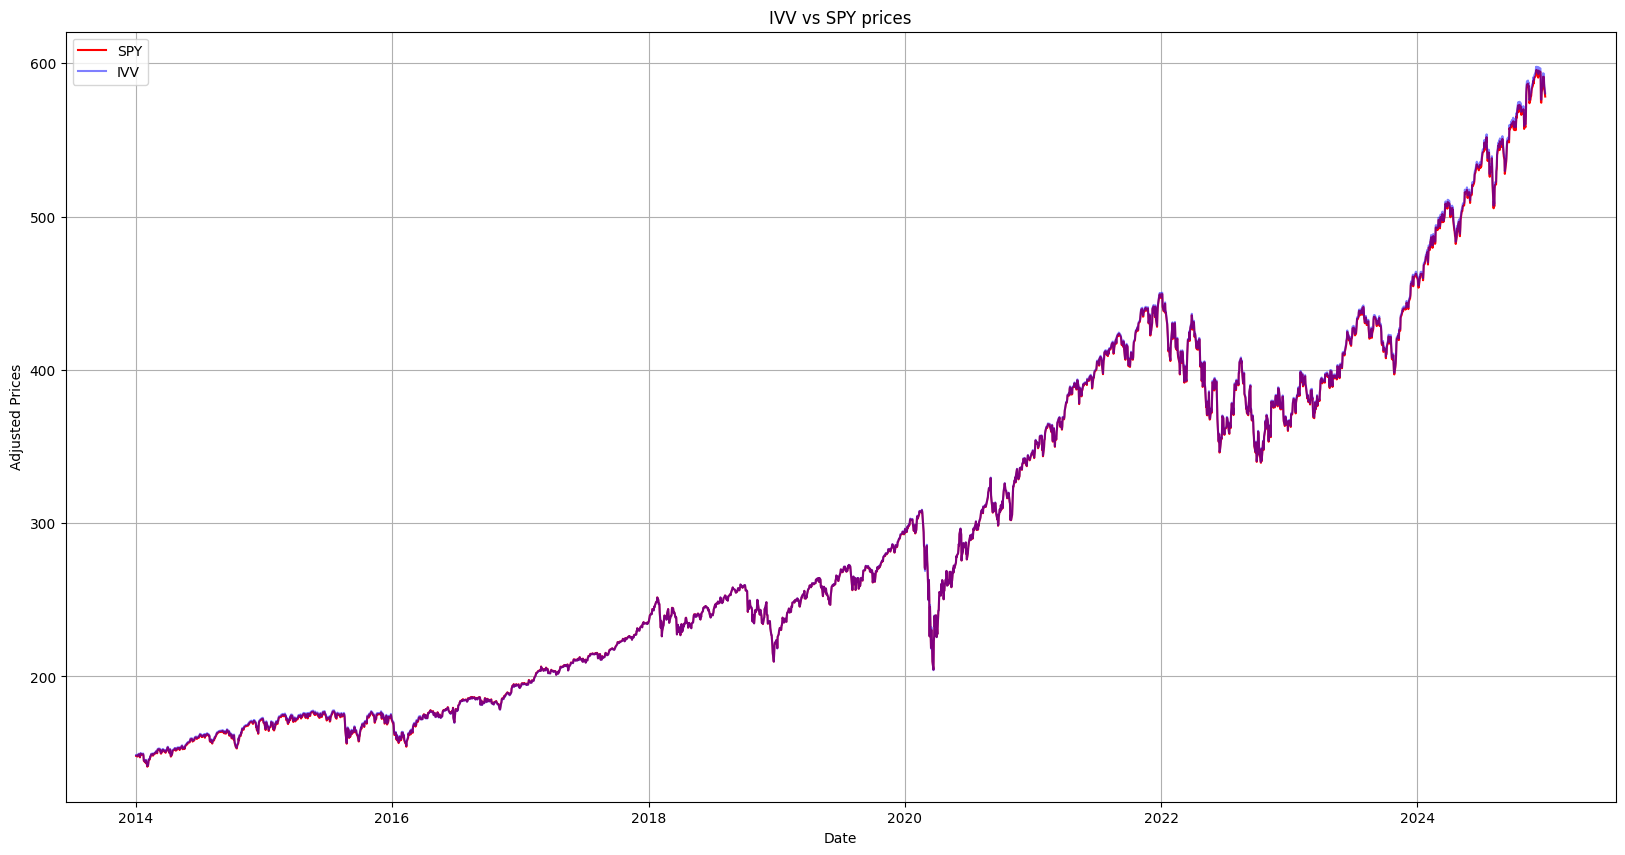

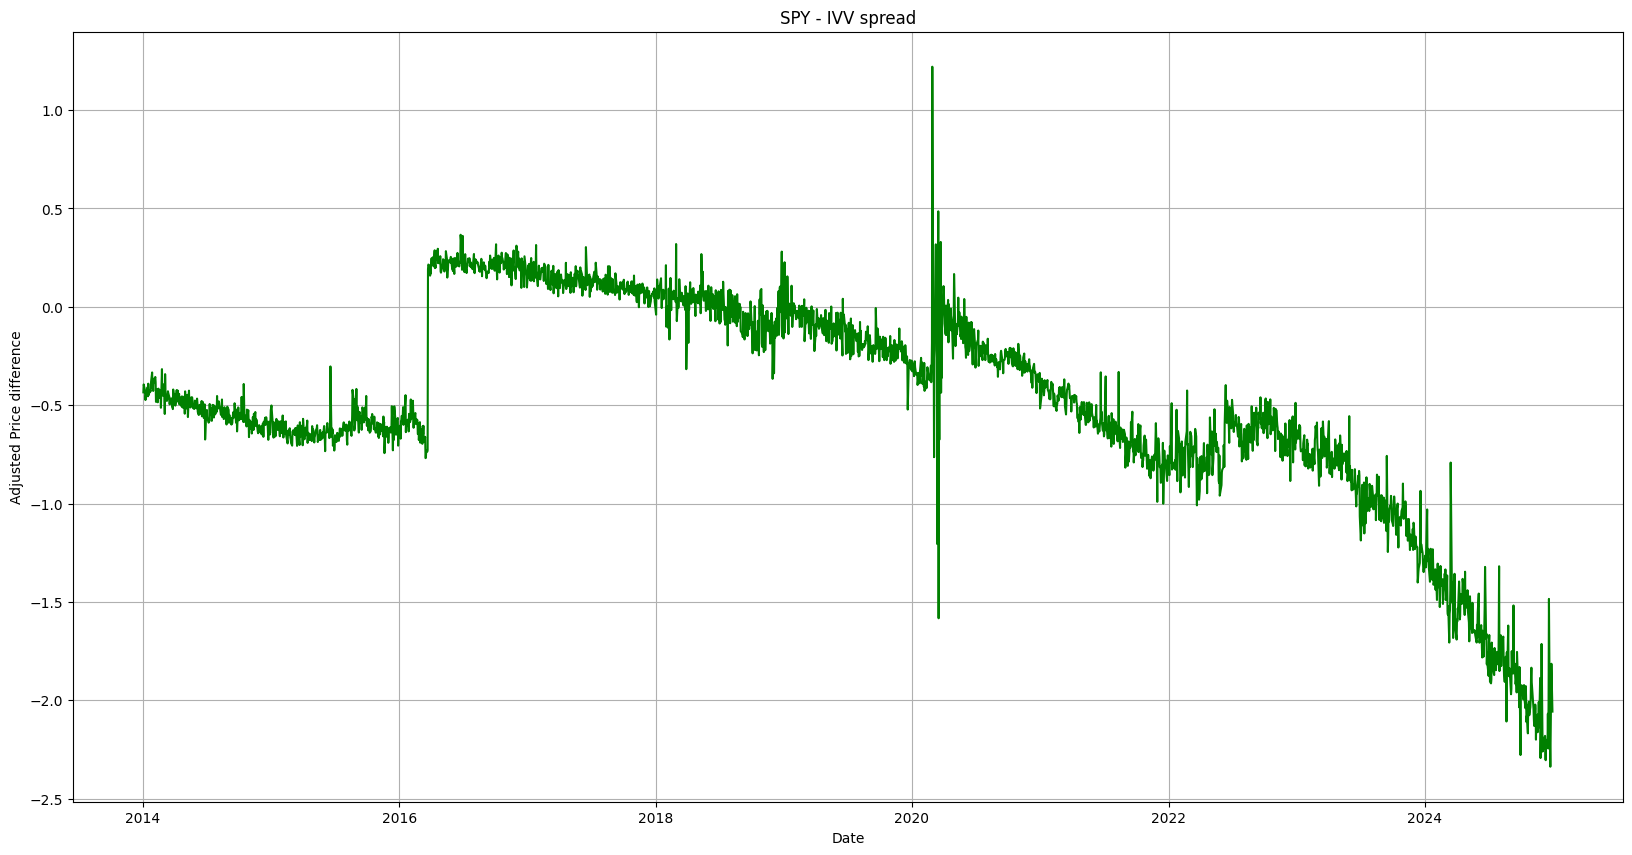

In [6]:
# Get both prices
spy = prices['SPY']
ivv = prices['IVV']

plt.figure(figsize=(20,10))
plt.plot(spy, label='SPY', color='red',)
plt.plot(ivv, label='IVV', color='blue',alpha=0.5)
plt.title('IVV vs SPY prices')
plt.xlabel('Date')
plt.ylabel('Adjusted Prices')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(20,10))
plt.plot(spy-ivv, label='SPY-IVV', color='green',)
plt.title('SPY - IVV spread')
plt.xlabel('Date')
plt.ylabel('Adjusted Price difference')
plt.grid(True)
plt.show()


From the above plots we note that even though SPY and IVV track the same index, the spread shows that there is a clear non-constant mean with a negative trend downwards post 2016. This importantly shows that even if two etfs track the same index, they may not be cointegrated.

## Correlation

In this part we wish to investigate the correlation of returns between SPY and IVV. First we plot the ratio of prices to further examine the behaviour linking these two etfs.

<Axes: title={'center': 'SPY / IVV ratio'}, xlabel='Date'>

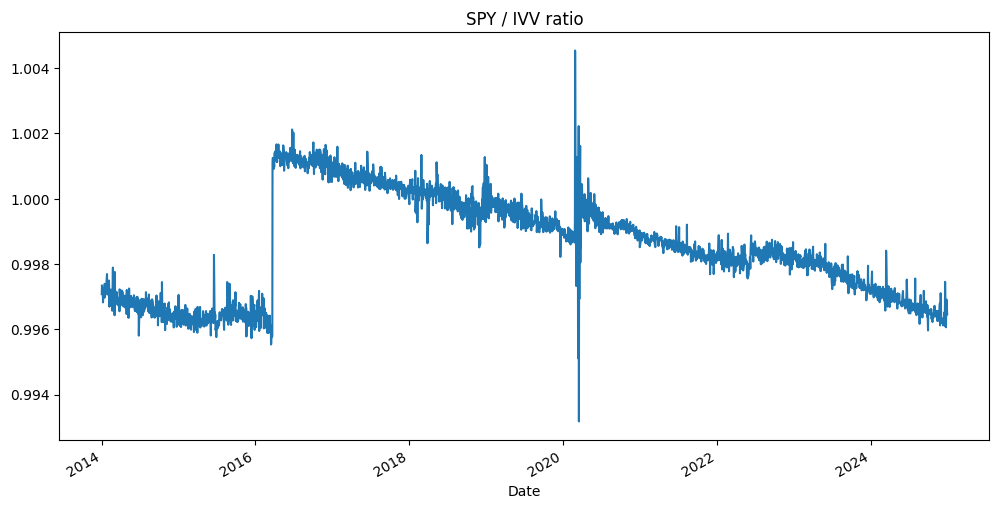

In [7]:
ratio = prices['SPY'] / prices['IVV']
ratio.plot(figsize=(12,6), title='SPY / IVV ratio')


In this plot, we see a similar pattern as in the SPY IVV spread, the trend moves downwards after 2016. One reason for the fact that SPY seems to be losing out over IVV in the long term is the expense ratio difference. When examining the expense ratios, we see IVV has a significantly lower ratio of 0.03% compared to the 0.0945% of SPY. This allows higher dividends for IVV than from SPY and thus better performance than SPY.

On the other hand, computing the correlations between returns and prices will give us a sense of how these equities perform in regard to each other.

          SPY       IVV
SPY  1.000000  0.999165
IVV  0.999165  1.000000
          SPY       IVV
SPY  1.000000  0.999995
IVV  0.999995  1.000000


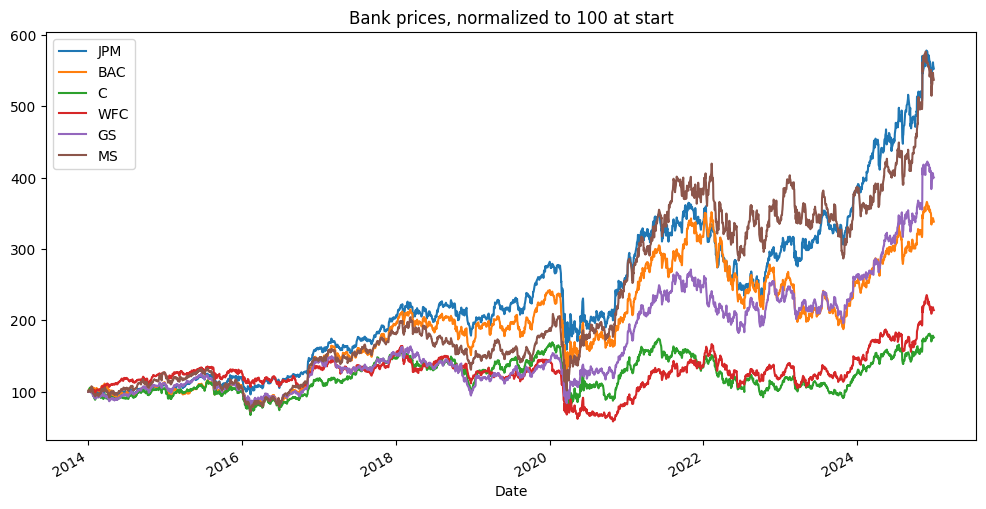

Return correlation:
      JPM   BAC     C   WFC    GS    MS
JPM  1.00  0.89  0.86  0.81  0.82  0.82
BAC  0.89  1.00  0.87  0.83  0.82  0.83
C    0.86  0.87  1.00  0.79  0.81  0.81
WFC  0.81  0.83  0.79  1.00  0.75  0.75
GS   0.82  0.82  0.81  0.75  1.00  0.86
MS   0.82  0.83  0.81  0.75  0.86  1.00

Price correlation:
      JPM   BAC     C   WFC    GS    MS
JPM  1.00  0.92  0.68  0.57  0.95  0.94
BAC  0.92  1.00  0.76  0.51  0.89  0.91
C    0.68  0.76  1.00  0.61  0.60  0.55
WFC  0.57  0.51  0.61  1.00  0.63  0.51
GS   0.95  0.89  0.60  0.63  1.00  0.97
MS   0.94  0.91  0.55  0.51  0.97  1.00


In [8]:
# Correlation of returns
print(returns[['SPY', 'IVV']].corr())

# Correlation of prices
print(prices[['SPY', 'IVV']].corr())

# Banks normalized prices
banks = get_universe('banks')
# Divide by initial position with .iloc[0] and * 100 to normalize to 100
normalized = prices[banks] / prices[banks].iloc[0] *100
normalized.plot(figsize=(12,6), title='Bank prices, normalized to 100 at start')
plt.show()

# Correlation matrices for banks
print("Return correlation:")
print(returns[banks].corr().round(2))
print("\nPrice correlation:")
print(prices[banks].corr().round(2))

